# Interpolation of JCOPE outputs from sigma to z coordinates

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from numba import njit, prange
import pandas as pd

In [3]:
# Define the experiment directory
dir_exp = os.path.expanduser('~/data/jcope/config/NWPAC025/run/')

# Suffix for inputs
suffix_in = "_01JAN1990.nc"

# Define the start date of the daily output (the dimension size is determined by the EL output)
start_date = "1990-01-01 12:00:00"
nt = xr.open_dataset(dir_exp+"EL"+suffix_in)["time"].size
# Generate the range
clean_time = pd.date_range(start=start_date, periods=nt, freq="D")

# Define Target Z-Levels (meters)
z_targets = np.array([
    0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 
    60, 70, 80, 90, 100, 125, 150, 175, 200, 
    250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000
], dtype=np.float32)

# Define your list of variables
list_var = [
    {
        "filename": "T",
        "varname": "tm",
        "units": "degC",
        "cfname": "sea_water_temperature"
    },
    {
        "filename": "S",
        "varname": "sm",
        "units": "psu",
        "cfname": "sea_water_salinity"
    },
    {
        "filename": "U",
        "varname": "um",
        "units": "m/s",
        "cfname": "eastward_sea_water_velocity"
    },
    {
        "filename": "V",
        "varname": "vm",
        "units": "m/s",
        "cfname": "northward_sea_water_velocity"
    },
    {
        "filename": "KH",
        "varname": "khm",
        "units": "m2/s",
        "cfname": "ocean_vertical_tracer_diffusivity"
    }
]

### Interpolation from sigma-coordinate to z-coordinate

In [4]:
def fix_jcope_dims(ds_in):
    # Fix JCOPE dimension to be in the order (t,z,y,x).
    # Get rid of dimension(s) of size 1, which is unnecessary.
    return ds_in.transpose("time","lev","lat","lon").squeeze()

# 1. Load grid data (basic)
ds_grid = xr.open_dataset(dir_exp+'basic_01JAN1999.nc')
ds_grid = fix_jcope_dims(ds_grid)
z_static = abs(ds_grid['zz'])  # zz values are negatives, so use abs() to convert to positives
# Bathymetry (H)
H = ds_grid['dz'].sum("lev")

# Load sea level data (EL)
ds_el = xr.open_dataset(dir_exp+"EL"+suffix_in)
ds_el = fix_jcope_dims(ds_el)
el = ds_el['elm']

# Calculate ACTUAL 3D Depth for each day
#    Formula: Z_static * (1 + EL / H)
z_daily = z_static * (1.0 + el / H)
z_daily = z_daily.transpose("time","lev","lat","lon")

@njit(parallel=True)
def interpolate_fast(z3d_in, in_da, z_targets, out_da):
    nz, nj, ni = in_da.shape
    
    # Numba likes explicit loops! 
    # Use 'prange' on the outer loop to use all CPU cores automatically
    for j in prange(nj):
        for i in range(ni):
            # Extract columns for depth and data (Standard numpy slicing works in Numba)
            col_z = z3d_in[:, j, i]
            col_da = in_da[:, j, i]
            
            # Numba supports np.interp
            out_da[:, j, i] = np.interp(z_targets, col_z, col_da)

for v in list_var:
    print(f"Interpolating {v['filename']}...")

    # Read the input data
    ds_in = xr.open_dataset(dir_exp+v["filename"]+suffix_in)
    ds_in = fix_jcope_dims(ds_in)
    da_in = ds_in[v["varname"]]
    nt, ny, nx = da_in["time"].size, da_in["lat"].size, da_in["lon"].size
    # Initialize the output array
    da_out = np.full((nt, len(z_targets), ny, nx), np.nan, dtype=np.float32)

    for t in range(nt):
        # Call Numba
        interpolate_fast(z_daily[t,:,:,:].values, da_in[t,:,:,:].values, z_targets, da_out[t,:,:,:])
        
    # Convert back to Xarray
    out_array = xr.DataArray(
        da_out,
        coords={
            "time": clean_time,       # Use clean_time
            "depth": z_targets,       # New Z coordinates
            "lat": ds_grid["lat"],         # Copy lat from the grid file
            "lon": ds_grid["lon"]          # Copy lon from the grid file
        },
        dims=("time", "depth", "lat", "lon"),
        name=v["varname"],
        attrs={
            "units": v["units"],
            "standard_name": v["cfname"]
        }
    )

    # Save to Disk
    out_filename = dir_exp+"interp_"+v['filename']+suffix_in
    
    # converting to dataset allows preserving global attributes easily
    ds_out = out_array.to_dataset()
    ds_out.to_netcdf(out_filename)
    
print ("Interpolation finished!")

Interpolating T...
Interpolating S...
Interpolating U...
Interpolating V...
Interpolating KH...


### basic.nc explained
The `basic` file in the JCOPE output contains grid data.

Dimensions:
- lon: longitude (range: 0 to 360 deg)
- lat: latitude (range: -90 to 90 deg)
- lev: vertical levels in integers starting from 1
- time: time only has one value which is static.

Variables (time, lev, lat, lon):
- z: the upper depth point (negative values)
- zz: the center depth point (negative values)
- dz: the vertical resolution (positive values; approximately equal to (z - zz)*2)

Text(0.5, 1.0, 'dz - (z-zz)*2 at lev=0')

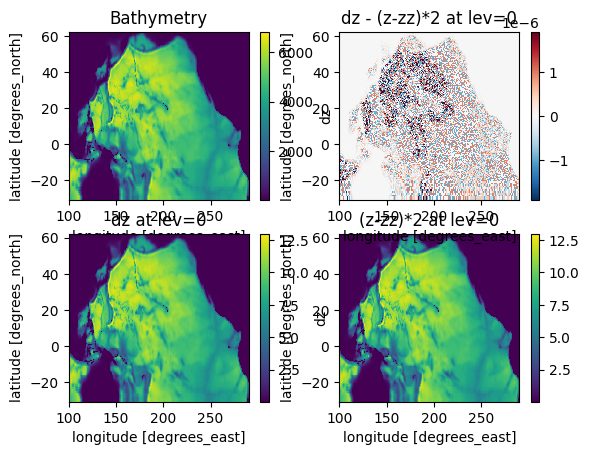

In [8]:
ds = xr.open_dataset(dir_exp+'basic_01JAN1999.nc')
plt.subplot(221)
ds["dz"].sum(dim=("lev")).plot()
plt.title('Bathymetry')
plt.subplot(223)
dz = ds["dz"][0,1,:,:]
dz.plot()
plt.title('dz at lev=0')
plt.subplot(224)
z_zz_x2 = ((ds["z"]-ds["zz"])[0,1,:,:]*2)
z_zz_x2.plot()
plt.title('(z-zz)*2 at lev=0')
plt.subplot(222)
(dz - z_zz_x2).plot()
plt.title('dz - (z-zz)*2 at lev=0')